## Conversion from Keras HGQ2 model to HLS4ML model (Verilog)

In [1]:
import os, subprocess
import shutil
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Keras 3
import keras

# Package imports
from bedposip.data import load_dataset
from bedposip.utils import inspect_hls4ml_precision, class_report_metric

import hls4ml
from hls4ml.model.profiling import numerical, compare



PROFILE = False
BUILD_IP = True
RESET_BUILD = True

I0000 00:00:1785118394.669823  663526 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

# Constant number of postures
NUM_CLASSES = 3

output_dir = str(Path("soft_ip").resolve())

X_TEST_PATH = str(Path("../dataset/output/X_test.npy").resolve())
Y_TEST_PATH = str(Path("../dataset/output/y_test.npy").resolve())

XPFM_PATH_CUSTOM = (
    "/home/jeison/Desktop/vitis_unified_backend_tutorial/exampleFile/pynq-z2_platform.xsa"
)

## Data

### Loading

In [3]:
# Load datasets using package function
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset()


Dataset shapes:
  Train: (119999, 8, 8, 1), labels: (119999,)
  Val:   (60000, 8, 8, 1), labels: (60000,)
  Test:  (120001, 8, 8, 1), labels: (120001,)


### Encoding

In [4]:
class_names = ["lateral_L", "lateral_R", "supine"]

## Model Loading

In [5]:
model_path = "output/posture_classifier_qat.keras"
model_qat = keras.models.load_model(model_path)
model_qat.summary()

I0000 00:00:1785118396.918014  663526 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4904 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6


Model: "posture_classifier_qat"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_1 (QConv2D)               │ (None, 6, 6, 24)       │           870 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qbn_conv_1                      │ (None, 6, 6, 24)       │           246 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_act_1 (Activation)        │ (None, 6, 6, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_2 (QConv2D)               │ (None, 4, 4, 20)       │        17,286 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qbn_conv_2                      │ (None, 4, 4, 20)       │           206 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_act_2 (Activation)        │ (None, 4, 4, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_3 (QConv2D)               │ (None, 2, 2, 36)       │        25,926 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qbn_conv_3                      │ (None, 2, 2, 36)       │           366 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_act_3 (Activation)        │ (None, 2, 2, 36)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_max_pooling2d (QMaxPooling2D) │ (None, 1, 1, 36)       │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_1 (QDense)               │ (None, 26)             │         3,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qbn_dense_1                     │ (None, 26)             │           266 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 26)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_2 (QDense)               │ (None, 10)             │         1,046 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qbn_dense_2                     │ (None, 10)             │           106 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (QDense)                 │ (None, 3)              │           138 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,100 (452.09 KB)

 Trainable params: 37,443 (146.26 KB)

 Non-trainable params: 12,769 (13.29 KB)

 Optimizer params: 74,888 (292.54 KB)

## Conversion

In [6]:
# Make Vitis available in path
script = "/home/jeison/AMD/Vitis/2023.2/settings64.sh"

for line in subprocess.check_output(f'source "{script}" >/dev/null && env', shell=True, executable='/bin/bash', text=True).splitlines():
    if '=' in line:
        k, v = line.split('=', 1)
        os.environ[k] = v

## HLS4ML

In [7]:
config = hls4ml.utils.config_from_keras_model(model_qat, granularity='name', backend='VitisUnified')

config['Model']['Strategy'] = 'Resource'
config['Model']['ReuseFactor'] = 72
config['Model']['IOType'] = 'io_stream'

config['LayerName']['qconv_1']['ReuseFactor'] = 9
config['LayerName']['qconv_1']['ParallelizationFactor'] = 1
config['LayerName']['qconv_1']['Trace'] = True

config['LayerName']['qconv_2']['ReuseFactor'] = 144
config['LayerName']['qconv_2']['ParallelizationFactor'] = 1
config['LayerName']['qconv_2']['Trace'] = True

config['LayerName']['qconv_3']['ReuseFactor'] = 144
config['LayerName']['qconv_3']['ParallelizationFactor'] = 1
config['LayerName']['qconv_3']['Trace'] = True

config['LayerName']['qdense_1']['ReuseFactor'] = 24
config['LayerName']['qdense_1']['Trace'] = True
config['LayerName']['qdense_2']['ReuseFactor'] = 42
config['LayerName']['qdense_2']['Trace'] = True

config['LayerName']['output']['ReuseFactor'] = 72
config['LayerName']['output']['Trace'] = True

# Enable the FIFO depth optimization flow
# config["Flows"] = ["vitisunified:fifo_depth_optimization"]
# hls4ml.model.optimizer.get_optimizer('vitisunified:fifo_depth_optimization').configure(profiling_fifo_depth=100_000)

# Convert model
hls_model = hls4ml.converters.convert_from_keras_model(
    model_qat,
    hls_config=config,
    output_dir=output_dir,
    backend='VitisUnified',
    part='xc7z020clg400-1', # Pynq-Z2
    board='pynq-z2',
    io_type='io_stream',
    clock_period="10ns",
    clock_uncertainty='12.5%',
    input_type="float", 
    output_type="float",
    # input_data_tb=X_TEST_PATH,
    # output_data_tb=Y_TEST_PATH,
    xpfmPath=XPFM_PATH_CUSTOM,
    axi_mode="axi_stream",
)

/home/jeison/Nextcloud/PUCMM/ProyectoGrado/.venv/lib/python3.13/site-packages/hls4ml/model/graph.py:483: UserWarning: Overriding attribute 'parallelization_factor' of layer 'qconv_1' (Conv2D):36 -> 1
  self.graph[name] = self.make_node(kind, name, layer, inputs, outputs)
/home/jeison/Nextcloud/PUCMM/ProyectoGrado/.venv/lib/python3.13/site-packages/hls4ml/model/graph.py:483: UserWarning: Overriding attribute 'parallelization_factor' of layer 'qconv_2' (Conv2D):16 -> 1
  self.graph[name] = self.make_node(kind, name, layer, inputs, outputs)
/home/jeison/Nextcloud/PUCMM/ProyectoGrado/.venv/lib/python3.13/site-packages/hls4ml/model/graph.py:483: UserWarning: Overriding attribute 'parallelization_factor' of layer 'qconv_3' (Conv2D):4 -> 1
  self.graph[name] = self.make_node(kind, name, layer, inputs, outputs)


## Profiling

In [8]:
# Compile and synthesize the model
hls_model.compile()

# Shows the median and quartiles of weight/activation distributions with box-and-whisker diagrams
# Grey box should cover the full range of the box-and-whisker plot

if PROFILE:
    wp, wph, ap, aph = numerical(
        model=model_qat,
        hls_model=hls_model,
        X=X_test,
        plot='boxplot'
    )

    compare(
        model_qat,
        hls_model,
        X_test,
        plot_type='dist_diff'
)

### Model


hls4ml Layer Precision Report:

Layer: pressure_map (Input)
  pressure_map: ufixed<8,8,RND,WRAP,0>

Layer: qconv_1 (Conv2D)
  accum_t:  fixed<16,10,TRN,WRAP,0>
  weight: fixed<8,2,TRN,WRAP,0>
  bias: ufixed<2,32,TRN,WRAP,0>
  qconv_1: fixed<9,9,RND,WRAP,0>

Layer: qbn_conv_1 (BatchNormalization)
  scale: ufixed<4,-2,TRN,WRAP,0>
  bias: fixed<7,3,TRN,WRAP,0>
  qbn_conv_1: fixed<8,7,TRN,WRAP,0>

Layer: qconv_act_1 (Activation)
  qconv_act_1: ufixed<5,5,RND,WRAP,0>

Layer: qconv_2 (Conv2D)
  accum_t:  fixed<15,10,TRN,WRAP,0>
  weight: fixed<6,1,TRN,WRAP,0>
  bias: ufixed<2,32,TRN,WRAP,0>
  qconv_2: fixed<9,6,RND,WRAP,0>

Layer: qbn_conv_2 (BatchNormalization)
  scale: ufixed<6,0,TRN,WRAP,0>
  bias: fixed<7,3,TRN,WRAP,0>
  qbn_conv_2: fixed<8,6,TRN,WRAP,0>

Layer: qconv_act_2 (Activation)
  qconv_act_2: ufixed<5,4,RND,WRAP,0>

Layer: qconv_3 (Conv2D)
  accum_t:  fixed<15,9,TRN,WRAP,0>
  weight: fixed<6,1,TRN,WRAP,0>
  bias: ufixed<2,32,TRN,WRAP,0>
  qconv_3: fixed<10,6,RND,WRAP,0>

Layer:

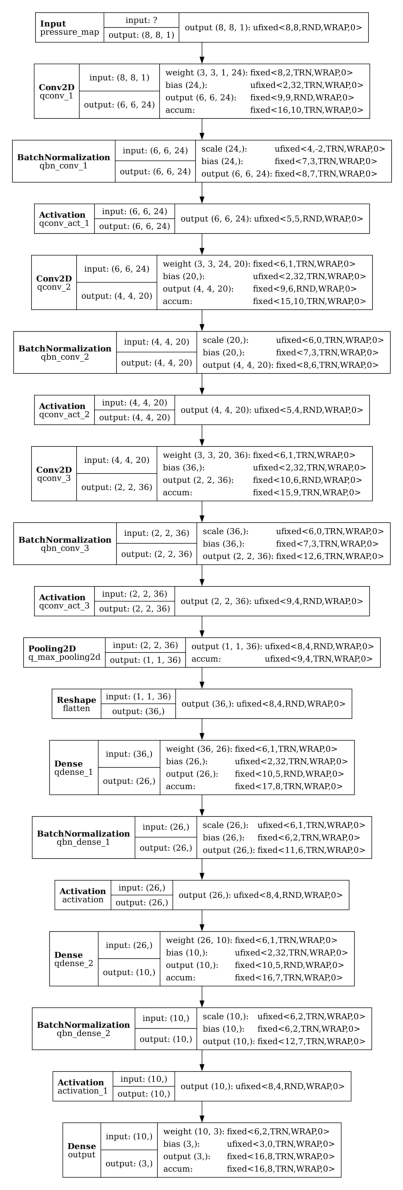

In [9]:
precision_info = inspect_hls4ml_precision(
    hls_model,
    report=True,
    save=True,
    model_name="hls_model",
)

### Evaluation

In [10]:
# Executes the FPGA firmware with bit-accurate emulation on the CPU.
y_keras, _, _ = class_report_metric(model_qat, X_test, y_test, class_names, show_report=False, show_cm=False) 
y_hls, _, _ = class_report_metric(hls_model, X_test, y_test, class_names, show_report=False, show_cm=False)

I0000 00:00:1785118412.617614  663589 service.cc:153] XLA service 0x7f382c0429a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785118412.617630  663589 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1785118412.687022  663589 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785118413.013953  663589 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1785118415.312932  663589 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Accuracy Report for `posture_classifier_qat`:
  Loss: 0.2407
  Accuracy: 90.86%


KeyboardInterrupt: 

In [ ]:
# Test for mismatches
# HGQ2 and hls4ml should produce the same output, up to machine precision
# Notice that due to the quantization, internal mismatches may be amplified, but the vast majority of the output should match
print(f"{np.sum(y_keras != y_hls)} / {np.prod(y_keras.shape)} value mismatches")

## Building

### Soft IP

In [ ]:
# Build with various options
if BUILD_IP:
    report = hls_model.build(
            reset=RESET_BUILD,   # Reset project before build
            csim=False,          # Run C simulation
            synth=True,          # Run HLS synthesis
            cosim=False,         # Run co-simulation
            fifo_opt=False,      # FIFO optimization
            bitfile=True,
            log_to_stdout=True,
        )


****** v++ v2023.2 (64-bit)
  **** SW Build 4026344 on 2023-10-11-15:42:10
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

Running Dispatch Server on port: 35329
INFO: [v++ 60-1548] Creating build summary session with primary output /home/jeison/Nextcloud/PUCMM/ProyectoGrado/model/soft_ip/vitis_workspace/myproject/vitis_unified_project/vitis_unified_project.hlscompile_summary, at Sun Jul 26 21:51:11 2026
INFO: [v++ 82-31] Launching vitis_hls: vitis_hls -nolog -run csynth -work_dir /home/jeison/Nextcloud/PUCMM/ProyectoGrado/model/soft_ip/vitis_workspace/myproject/vitis_unified_project -config /home/jeison/Nextcloud/PUCMM/ProyectoGrado/model/soft_ip/hls_kernel_config.cfg -cmdlineconfig /home/jeison/Nextcloud/PUCMM/ProyectoGrado/model/soft_ip/vitis_workspace/myproject/vitis_unified_project/hls/config.cmdline

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2023.2 (64-bit)
  **** SW 

### Report

In [ ]:
if BUILD_IP:
    # Latency (cycles)
    best_latency = int(report['CSynthesisReport']['BestLatency'])
    worst_latency = int(report['CSynthesisReport']['WorstLatency'])
    print(f"Latency: {best_latency} - {worst_latency} cycles")

    # Clock (ns)
    target_clock = float(report['CSynthesisReport']['TargetClockPeriod'])
    estimated_clock = float(report['CSynthesisReport']['EstimatedClockPeriod'])
    print(f"Target Clock = {target_clock} ns | Estimated Clock = {estimated_clock} ns")

    # Available resources
    avail_LUT = int(report['CSynthesisReport']['AvailableLUT'])
    avail_FF = int(report['CSynthesisReport']['AvailableFF'])
    avail_DSP = int(report['CSynthesisReport']['AvailableDSP'])
    avail_BRAM = int(report['CSynthesisReport']['AvailableBRAM_18K'])

    # Used resources (Vitis HLS)
    used_LUT = int(report['CSynthesisReport']['LUT'])
    used_FF = int(report['CSynthesisReport']['FF'])
    used_DSP = int(report['CSynthesisReport']['DSP'])
    used_BRAM = int(report['CSynthesisReport']['BRAM_18K'])

    # Calculate percentages
    used_LUT_pct = (used_LUT / avail_LUT) * 100
    used_FF_pct = (used_FF / avail_FF) * 100
    used_DSP_pct = (used_DSP / avail_DSP) * 100
    used_BRAM_pct = (used_BRAM / avail_BRAM) * 100

    # Vitis HLS Resources
    print(f"\n--- Vitis HLS Resource Utilization ---")
    print(f"LUT:  {used_LUT:>6} / {avail_LUT:>6} ({used_LUT_pct:>5.2f}%)")
    print(f"FF:   {used_FF:>6} / {avail_FF:>6} ({used_FF_pct:>5.2f}%)")
    print(f"DSP:  {used_DSP:>6} / {avail_DSP:>6} ({used_DSP_pct:>5.2f}%)")
    print(f"BRAM: {used_BRAM:>6} / {avail_BRAM:>6} ({used_BRAM_pct:>5.2f}%)")

    # Used resources (Vivado)
    # used_LUT_v = int(report['VivadoSynthReport']['LUT'])
    # used_FF_v = int(report['VivadoSynthReport']['FF'])
    # used_DSP_v = int(report['VivadoSynthReport']['DSP48E'])
    # used_BRAM_v = int(report['VivadoSynthReport']['BRAM_18K'])

    # Calculate percentages
    # used_LUT_v_pct = (used_LUT_v / avail_LUT) * 100
    # used_FF_v_pct = (used_FF_v / avail_FF) * 100
    # used_DSP_v_pct = (used_DSP_v / avail_DSP) * 100
    # used_BRAM_v_pct = (used_BRAM_v / avail_BRAM) * 100

    # Vivado Synthesis Resources
    # print(f"\n--- Vivado Synthesis Resource Utilization ---")
    # print(f"LUT:  {used_LUT_v:>6} / {avail_LUT:>6} ({used_LUT_v_pct:>5.2f}%)")
    # print(f"FF:   {used_FF_v:>6} / {avail_FF:>6} ({used_FF_v_pct:>5.2f}%)")
    # print(f"DSP:  {used_DSP_v:>6} / {avail_DSP:>6} ({used_DSP_v_pct:>5.2f}%)")
    # print(f"BRAM: {used_BRAM_v:>6} / {avail_BRAM:>6} ({used_BRAM_v_pct:>5.2f}%)")

TypeError: 'NoneType' object is not subscriptable